# 21.3    Setter und Getter und Property Attributes Zur vorigen ÜberschriftZur nächsten Überschrift
21.3.1    Setter und Getter Zur vorigen ÜberschriftZur nächsten Überschrift

Ein Konzept der objektorientierten Programmierung, um den Zugriff auf Attribute zu steuern, stellen die Setter-Methoden und Getter-Methoden dar. Anstatt direkt auf das Attribut zuzugreifen, wird der Zugriff dabei über spezielle Methoden geregelt.

Um das folgende Beispiel übersichtlich zu halten, werden wir eine neue Klasse A einführen, die ein über Setter- und Getter-Methoden verwaltetes Attribut besitzt. Die Übertragung auf das Kontobeispiel ist dann eine einfache Übungsaufgabe.

https://openbook.rheinwerk-verlag.de/python/21_003.html#u21.3

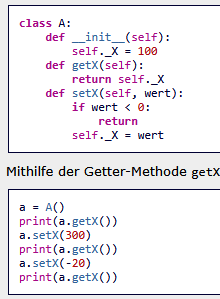



In [2]:
# without property:
class A:
    def __init__(self):
        self._X = 100       
    def getX(self):
        return self._X    
    def setX(self, wert):
        if wert < 0:
            return
        self._X = wert

In [3]:
a = A()
print(a.getX())
a.setX(300)
print(a.getX())
a.setX(-20)
print(a.getX())

100
300
300


# 21.3.2    Property-Attribute Zur vorigen Überschrift Zur nächsten Überschrift

Die explizite Verwaltung von Attributen mittels Setter- und Getter-Methoden ist unschön, da man nun bei der Benutzung einer Klasse zwischen Attributen unterscheiden muss, die man direkt verwenden darf, und solchen, deren Zugriffe durch Setter- und Getter-Methoden gesteuert werden müssen.

Die sogenannten Property-Attribute lösen dieses Problem, indem Setter- und Getter-Methoden beim Schreiben bzw. Lesen eines Attributs implizit aufgerufen werden.

Wir können damit unsere Klasse so anpassen, dass sie sich folgendermaßen verwenden lässt und wir trotzdem für gültige Belegungen von X sorgen können:

https://chatgpt.com/c/69594081-c080-832a-81ca-c66cbe339184


In [ ]:
class A:
    def __init__(self):
        self._X = 100        
    def getX(self):
        print("Getter gerufen")
        return self._X    
    def setX(self, wert):
        print("Setter gerufen")
        if wert < 0:
            return 
        self._X = wert
    X = property(getX, setX)
a = A()
a.X = 300
print(a.X)
a.X = -20
print(a.X)

# Minimaler Getter-Descriptor
https://chatgpt.com/c/69594081-c080-832a-81ca-c66cbe339184

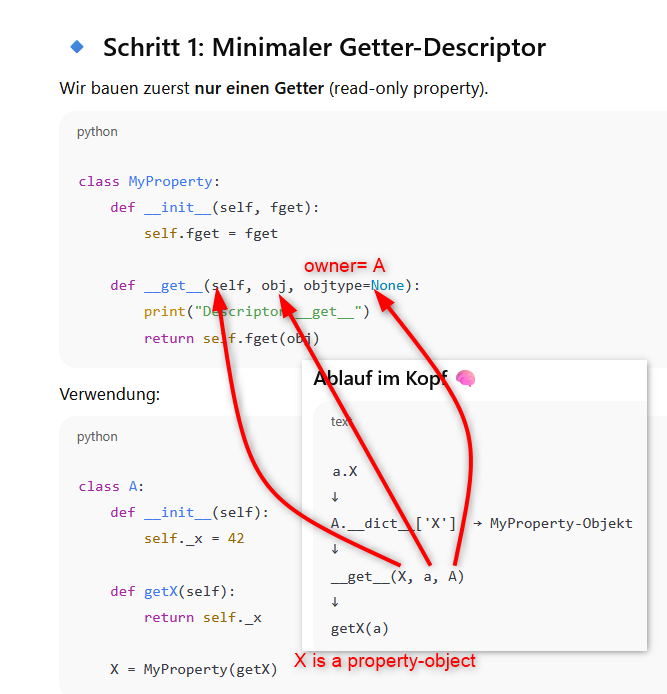


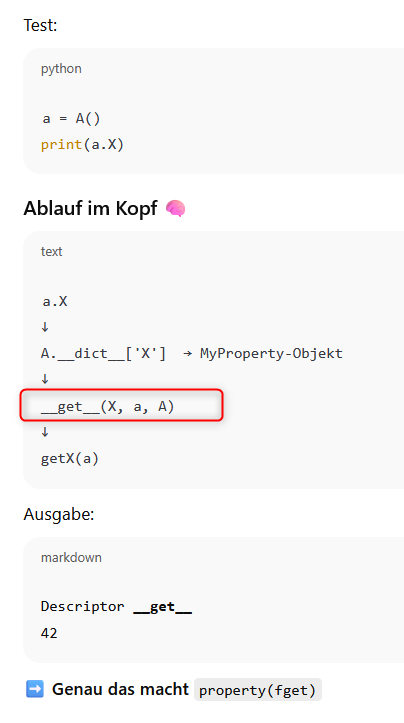

# @property nachbauen (Decorator-Style)
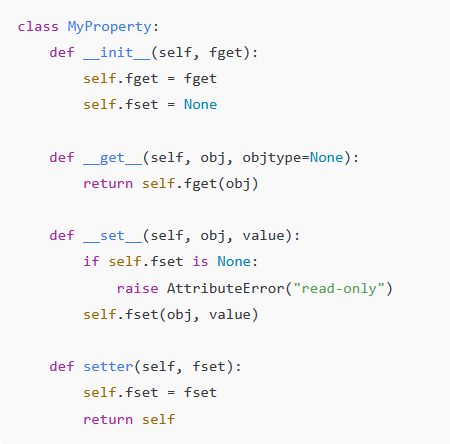

In [5]:
class MyProperty:
    def __init__(self, fget):
        self.fget = fget
        self.fset = None

    def __get__(self, obj, objtype=None):
        return self.fget(obj)

    def __set__(self, obj, value):
        if self.fset is None:
            raise AttributeError("read-only")
        self.fset(obj, value)

    def setter(self, fset):
        self.fset = fset
        return self

In [8]:
class A:
    def __init__(self):
        self._x = 50

    @MyProperty
    def X(self):
        return self._x

    @X.setter
    def X(self, value):
        self._x = value


In [7]:
a = A()
a.X = 123
print(a.X)

123


In [9]:
class property:
    def __init__(self, fget, fset, fdel, doc):
        self.fget = fget
        self.fset = fset
        self.fdel = fdel
        self.__doc__ = doc

    def setter(self, fset):
        return property(self.fget, fset, self.fdel, self.__doc__)
